##**5. Unsupervised Machine Learning**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

###**5.1 The Elbow Method**

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

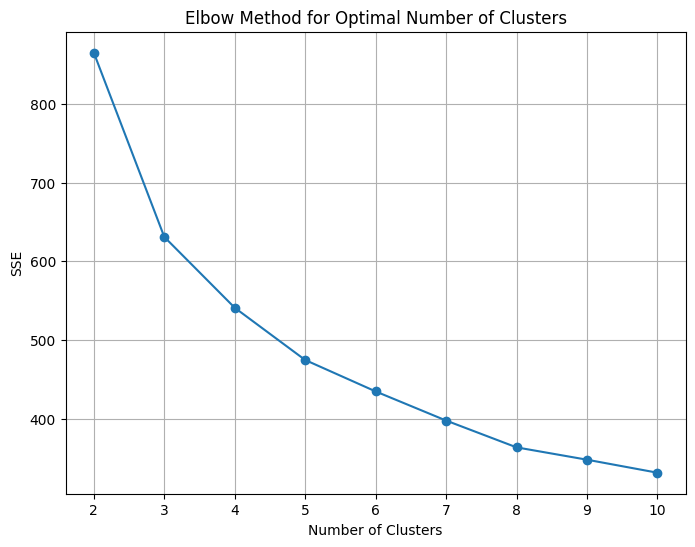

In [ ]:
# Determine the optimal number of clusters using the Elbow Method
sse = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(normalized_features)
    sse.append(kmeans.inertia_)

# Plotting the Elbow Method results
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.grid(True)
plt.show()

The Elbow Method plot shows a gradual decrease in the Sum of Squared Errors as the number of clusters increases. The "elbow" point, which suggests the optimal number of clusters, is not sharply defined but seems to be within 3 to 4 clusters.

###**5.2 K-Means Clustering**

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Silhouette Score for 3 clusters: 0.37
Cluster Characteristics:
         Population 2015  Average Age 2015  Average Income  \
Cluster                                                      
0            1817.770518         35.291350    52748.823837   
1            1872.491397         36.565434    59037.302134   
2            1677.669843         38.412285    66356.092580   

         Employment Rate 2011  PT Accessibility Levels 2014  \
Cluster                                                       
0                   57.681443                      3.820491   
1                   63.060564                      4.245699   
2                   67.885977                      3.149149   

         Median House Price 2023  Index of Multiple Deprivation  \
Cluster                                                           
0                  521242.049695                    9236.922112   
1                  619518.300177                   14751.854095   
2                  779834.000548          

<ipython-input-23-09d214d37256>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
<ipython-input-23-09d214d37256>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
<ipython-input-23-09d214d37256>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm'

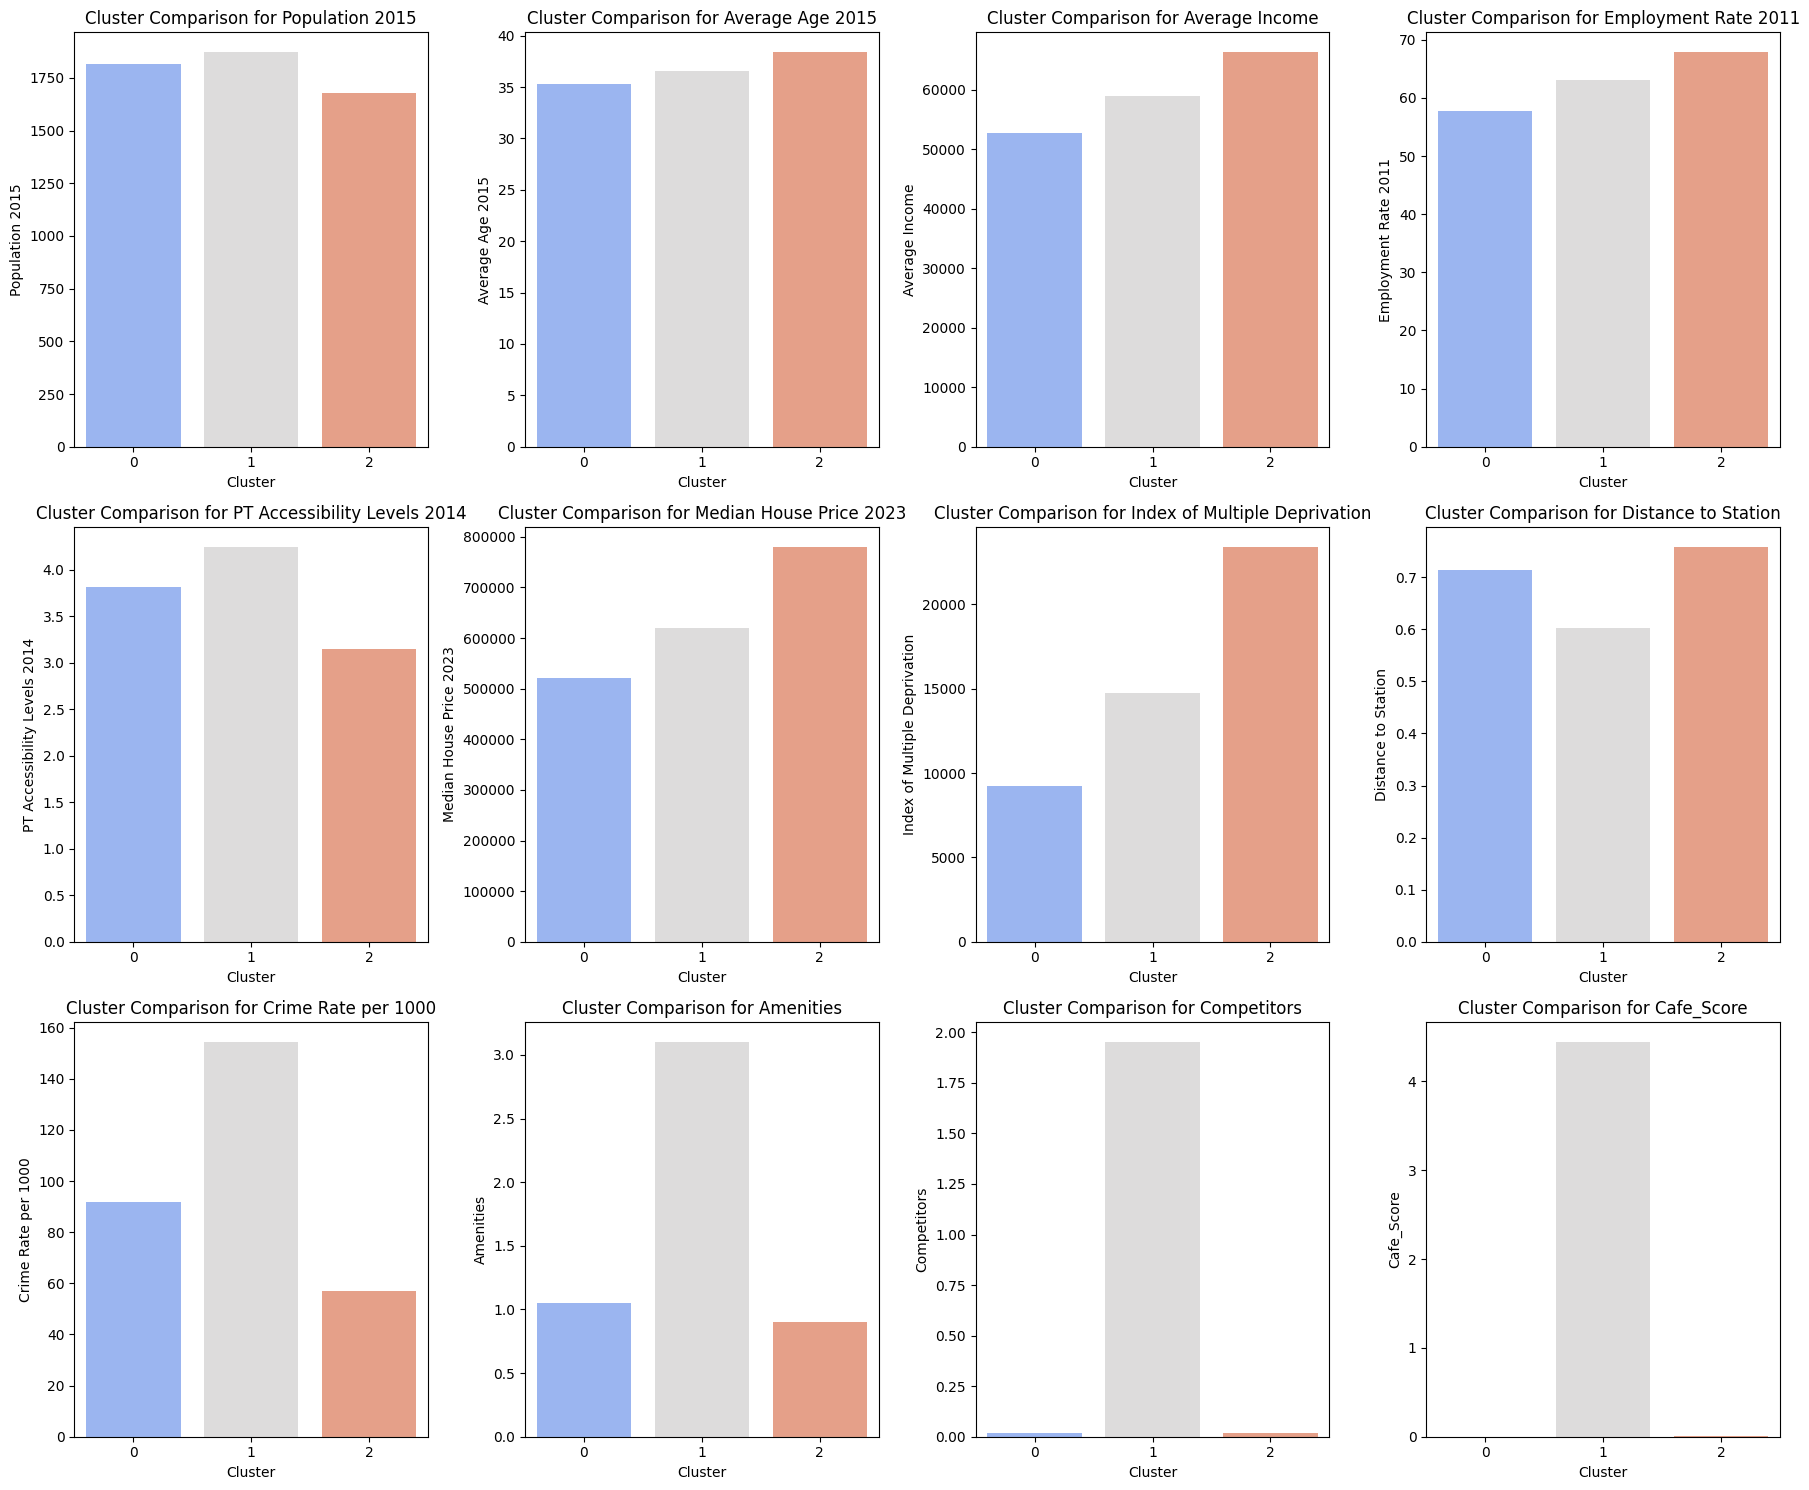

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import geopandas as gpd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 1: Apply K-Means Clustering

# Define the optimal number of clusters
optimal_k = 3

# Apply K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(normalized_features)

# Evaluate the K-Means clustering
silhouette_avg = silhouette_score(normalized_features, data['Cluster'])
print(f'Silhouette Score for {optimal_k} clusters: {silhouette_avg:.2f}')

# Analyze the characteristics of each cluster (without further normalization)
cluster_characteristics = data[numeric_features + ['Cluster']].groupby('Cluster').mean()

# Display the cluster characteristics
print("Cluster Characteristics:")
print(cluster_characteristics)

# Visualize the characteristics of each cluster using bar plots
num_features = len(cluster_characteristics.columns)
num_cols = 4  # Number of columns in the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
axes = axes.flatten()  # Flatten the array of axes for easy iteration

for i, feature in enumerate(cluster_characteristics.columns):
    sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Cluster Comparison for {feature}')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(f'{feature}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**1. Cluster 0 Interpretation:** Cluster 0 represents areas that have a relatively younger population with the lowest income and house prices. These areas are less deprived, have moderate public transport accessibility, and a moderate crime rate. However, these areas also have the least number of amenities and competitors, and the lowest café score, suggesting limited café success potential.

**Success Level:** Likely categorised as Low Success due to limited amenities, lower income, and café score.

**2. Cluster 1 Interpretation:** Cluster 1 represents areas with a moderate population density, income, and age. These areas are characterised by the highest public transport accessibility, the highest number of amenities, and a high café score. However, they also have the highest crime rate, which could be a deterrent. The high number of competitors indicates a saturated market, but the café score suggests that the café business is thriving despite the competition.  
**Success Level:** Likely categorised as High Success due to high café score, amenities, and public transport accessibility, despite the high crime rate.

**3. Cluster 2 Interpretation:** Cluster 2 represents more affluent areas with the highest income and house prices. These areas have the oldest population and the highest employment rate. However, they are also the most deprived, have the lowest public transport accessibility, and the lowest number of competitors. The café score is low, indicating that café success might be limited despite the affluence.
**Success Level:** Likely categorised as Moderate Success due to affluence and low crime rate but hindered by high deprivation, low café score, and public transport accessibility.

**Summary:**

Cluster 0 - Low Success: Least deprived, lowest amenities, and café score.

Cluster 1 - High Success: Highest café score, amenities, and public transport accessibility despite high crime.

Cluster 2 - Moderate Success: Affluent areas with low café score and high deprivation.

###**Visualize K-Means Clusters**

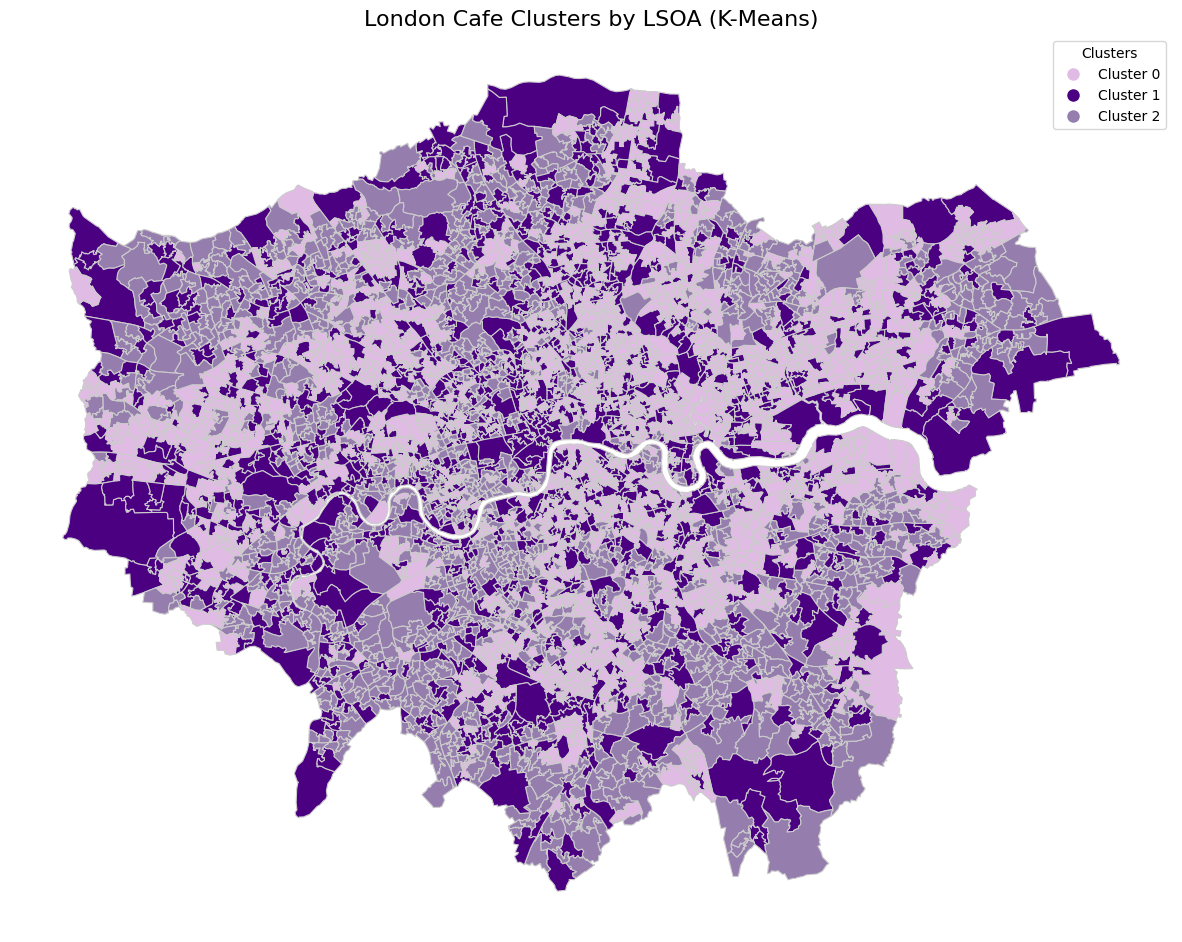

In [ ]:
# Load the shapefile
shapefile_path = 'LSOA_2011_London_gen_MHW.shp'  # Update this path if necessary
gdf = gpd.read_file(shapefile_path)

# Merge the GeoDataFrame with your LSOA cluster data
merged_data = pd.merge(data[['LSOA Code', 'Cluster']], gdf, left_on='LSOA Code', right_on='LSOA11CD', how='left')

# Ensure the merged_data is treated as a GeoDataFrame
merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Updated cluster colors using a gradient of red
cluster_colors = {
    0: '#E0BBE4', # Low Success
    1: '#4B0082', # High Success
    2: '#957DAD'  # Moderate Success
}

# Map the colors to the clusters
merged_data['color'] = merged_data['Cluster'].map(cluster_colors)

# Plot the LSOA areas with a color map based on 'Cluster'
merged_data.plot(color=merged_data['color'], linewidth=0.8, ax=ax, edgecolor='0.8')

# Add a title
plt.title('London Cafe Clusters by LSOA (K-Means)', fontsize=16)

# Remove axis for better visualization
ax.set_axis_off()

# Update the legend to reflect the pastel colors
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}',
                          markersize=10, markerfacecolor=color)
                   for cluster, color in cluster_colors.items()]
ax.legend(handles=legend_elements, title='Clusters')

# Display the plot
plt.show()


From the subplot visualisation we can see that:

**Cluster 0:** Represents more deprived areas with lower income and fewer amenities but could be a target for budget-friendly cafes.

**Cluster 1:** This cluster is highly commercial with many competitors, making it a more competitive but potentially lucrative area.

**Cluster 2:** Despite its high crime rate, this cluster has high public transport accessibility, which could attract foot traffic.

**Cluster 3:** This cluster seems to represent affluent, less deprived areas with high house prices and income, potentially ideal for premium cafe locations.


**K-Means Clustering Evaluation:** Although the elbow point suggested 3 to 4 clusters, the Silhouette Scores across different numbers of clusters were relatively low (ranging from 0.33 to 0.37). This score, which measures how similar an object is to its own cluster compared to other clusters, was consistently below 0.5, indicating weak and overlapping clusters.
Observations:

Overall, the clusters formed by K-Means showed limited differentiation in several features, such as population, income, and amenities. This lack of clear separation suggests that K-Means struggled to capture the underlying structure of the data.

###**5.3 DBSCAN Clustering Analysis**

The next step is to explore an alternative clustering approach using DBSCAN (Density-Based Spatial Clustering of Applications with Noise), which identifies clusters based on the density of data points and does not require the number of clusters to be specified beforehand.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Adjusted DBSCAN parameters
dbscan = DBSCAN(eps=0.3, min_samples=5)  # You may need to experiment with these values
data['Cluster'] = dbscan.fit_predict(normalized_features)

# Check if DBSCAN found more than one cluster
if len(set(data['Cluster'])) > 1:  # Ensure more than one cluster
    # Exclude noise points labeled as -1
    silhouette_avg = silhouette_score(normalized_features[data['Cluster'] != -1], data['Cluster'][data['Cluster'] != -1])
    print(f'Silhouette Score for DBSCAN clusters: {silhouette_avg:.2f}')
else:
    print("DBSCAN did not find distinct clusters or labeled most points as noise. Try adjusting `eps` and `min_samples`.")

# Silhouette Score
silhouette_avg = silhouette_score(normalized_features, data['Cluster'])
print(f'Silhouette Score for Agglomerative Clustering: {silhouette_avg:.2f}')

# Analyze the characteristics of each cluster (without further normalization)
cluster_characteristics = data[numeric_features + ['Cluster']].groupby('Cluster').mean()

# Display the cluster characteristics
print("Cluster Characteristics:")
print(cluster_characteristics)


Silhouette Score for DBSCAN clusters: 0.49
Silhouette Score for Agglomerative Clustering: 0.48
Cluster Characteristics:
         Population 2015  Average Age 2015  Average Income  \
Cluster                                                      
-1           2036.540984         39.078042    71898.360656   
 0           1755.161598         36.621712    58544.424568   
 1           1867.310563         36.518728    58748.591549   

         Employment Rate 2011  PT Accessibility Levels 2014  \
Cluster                                                       
-1                  59.095082                      5.157377   
 0                  62.150089                      3.524031   
 1                  63.126690                      4.203873   

         Median House Price 2023  Index of Multiple Deprivation  \
Cluster                                                           
-1                  1.701726e+06                   21197.426230   
 0                  6.236898e+05                   1

**Hyperparamenters Fine-tuning**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

best_silhouette = -1
best_eps = None
best_min_samples = None

# Define a range of eps and min_samples values to test
eps_values = np.arange(0.1, 1.0, 0.1)
min_samples_values = range(3, 10)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        data['Cluster'] = dbscan.fit_predict(normalized_features)

        # Count the number of clusters excluding noise
        unique_labels = set(data['Cluster'])
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        # Check if more than one valid cluster is identified
        if n_clusters > 1:
            try:
                # Calculate the Silhouette Score, excluding noise points
                silhouette_avg = silhouette_score(normalized_features[data['Cluster'] != -1],
                                                  data['Cluster'][data['Cluster'] != -1])
                print(f'Eps: {eps}, Min Samples: {min_samples}, Silhouette Score: {silhouette_avg:.2f}')

                # Save the best parameters and score
                if silhouette_avg > best_silhouette:
                    best_silhouette = silhouette_avg
                    best_eps = eps
                    best_min_samples = min_samples
            except ValueError as e:
                print(f"Skipping Silhouette Score calculation for Eps: {eps}, Min Samples: {min_samples} due to error: {e}")

# Print the best parameters
if best_eps is not None and best_min_samples is not None:
    print(f'Best Eps: {best_eps}, Best Min Samples: {best_min_samples}, Best Silhouette Score: {best_silhouette:.2f}')

    # Re-run DBSCAN with the best parameters
    dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    data['Cluster'] = dbscan.fit_predict(normalized_features)

    # Analyze the characteristics of each cluster (without further normalization)
    cluster_characteristics = data[numeric_features + ['Cluster']].groupby('Cluster').mean()



Eps: 0.1, Min Samples: 3, Silhouette Score: -0.41
Eps: 0.1, Min Samples: 4, Silhouette Score: -0.44
Eps: 0.1, Min Samples: 5, Silhouette Score: -0.15
Eps: 0.1, Min Samples: 6, Silhouette Score: -0.16
Eps: 0.1, Min Samples: 7, Silhouette Score: -0.38
Eps: 0.1, Min Samples: 8, Silhouette Score: -0.02
Eps: 0.1, Min Samples: 9, Silhouette Score: -0.06
Eps: 0.2, Min Samples: 3, Silhouette Score: 0.26
Eps: 0.2, Min Samples: 4, Silhouette Score: 0.30
Eps: 0.2, Min Samples: 5, Silhouette Score: 0.44
Eps: 0.2, Min Samples: 6, Silhouette Score: 0.33
Eps: 0.2, Min Samples: 7, Silhouette Score: 0.51
Eps: 0.2, Min Samples: 8, Silhouette Score: 0.51
Eps: 0.2, Min Samples: 9, Silhouette Score: 0.51
Eps: 0.30000000000000004, Min Samples: 3, Silhouette Score: 0.43
Eps: 0.30000000000000004, Min Samples: 4, Silhouette Score: 0.49
Eps: 0.30000000000000004, Min Samples: 5, Silhouette Score: 0.49
Eps: 0.30000000000000004, Min Samples: 6, Silhouette Score: 0.49
Eps: 0.30000000000000004, Min Samples: 7, Silho

**Re-run DBSCAN with the best parameters**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Best DBSCAN parameters
eps = 0.2
min_samples = 7

# Apply DBSCAN with the best parameters
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
data['Cluster'] = dbscan.fit_predict(normalized_features)

# Evaluate the Silhouette Score
if len(set(data['Cluster'])) > 1:  # Ensure more than one cluster
    silhouette_avg = silhouette_score(normalized_features[data['Cluster'] != -1],
                                      data['Cluster'][data['Cluster'] != -1])
    print(f'Silhouette Score for DBSCAN clusters with eps={eps} and min_samples={min_samples}: {silhouette_avg:.2f}')

# Analyze the characteristics of each cluster (without further normalization)
cluster_characteristics = data[numeric_features + ['Cluster']].groupby('Cluster').mean()

# Display the cluster characteristics
print("Cluster Characteristics:")
print(cluster_characteristics)


Silhouette Score for DBSCAN clusters with eps=0.2 and min_samples=7: 0.51
Cluster Characteristics:
         Population 2015  Average Age 2015  Average Income  \
Cluster                                                      
-1           1934.561404         37.807767    67186.549708   
 0           1752.977315         36.585344    58224.739424   
 1           1854.419171         36.391493    57887.814785   

         Employment Rate 2011  PT Accessibility Levels 2014  \
Cluster                                                       
-1                  62.105848                      5.329532   
 0                  62.160668                      3.464684   
 1                  63.109504                      4.044842   

         Median House Price 2023  Index of Multiple Deprivation  \
Cluster                                                           
-1                  1.029781e+06                   18010.798246   
 0                  6.091996e+05                   15246.059166   
 1    

**Create subplots for each feature**

<ipython-input-28-04775e36e395>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
<ipython-input-28-04775e36e395>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
<ipython-input-28-04775e36e395>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
<

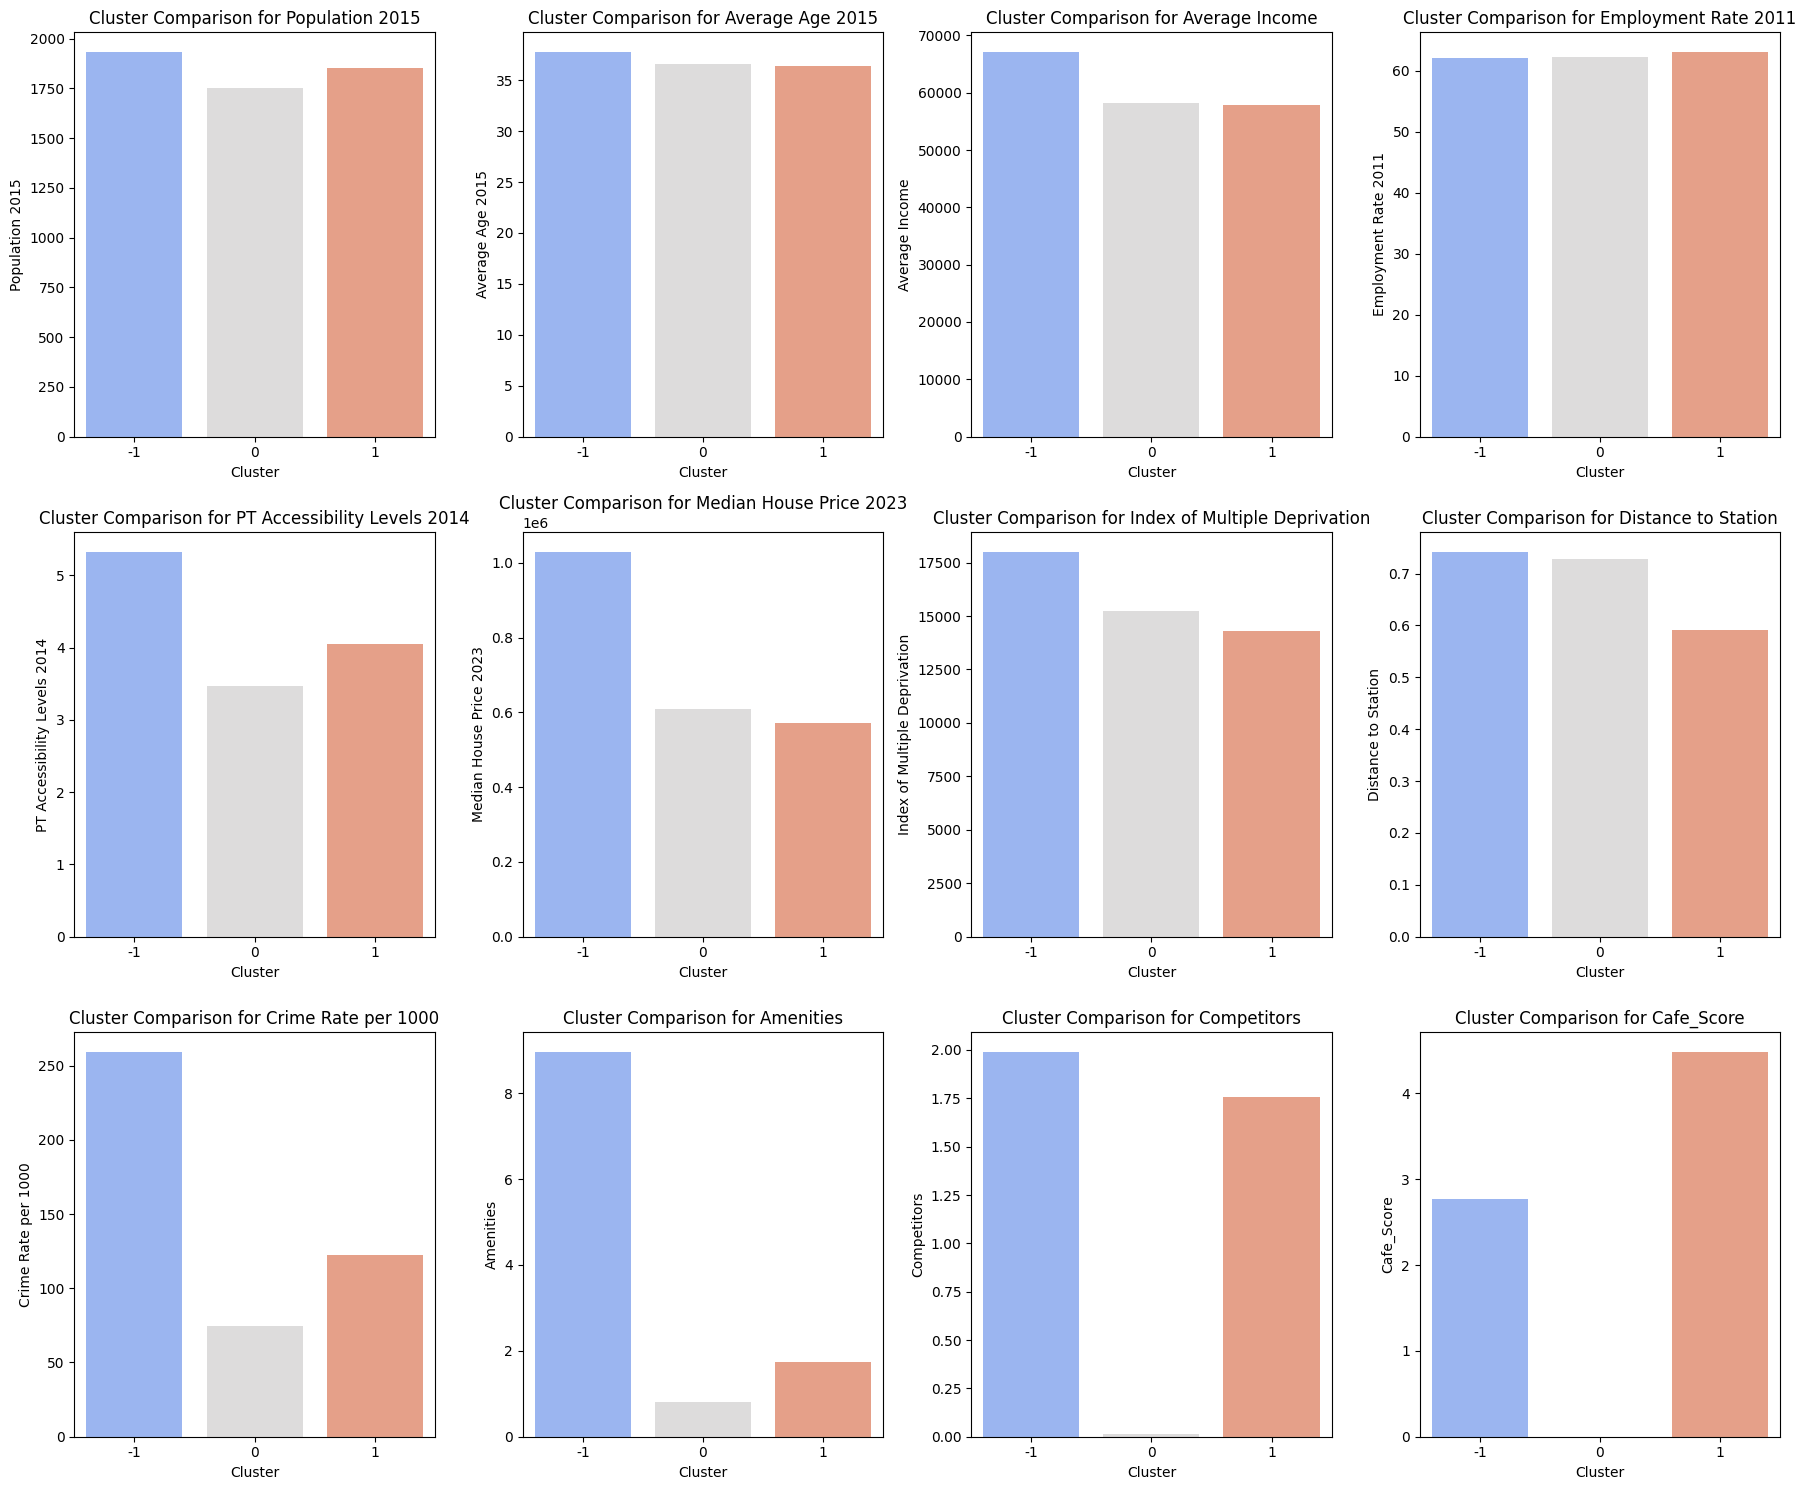

In [ ]:

num_features = len(cluster_characteristics.columns)
num_cols = 4  # Number of columns in the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
axes = axes.flatten()  # Flatten the array of axes for easy iteration

for i, feature in enumerate(cluster_characteristics.columns):
    sns.barplot(x=cluster_characteristics.index, y=cluster_characteristics[feature], ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Cluster Comparison for {feature}')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(f'{feature}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

DBSCAN parameters (eps = 0.2, min_samples = 7) were optimized, yielding a Silhouette Score of 0.51, superior to K-Means.
Noise and Cluster Characteristics:

DBSCAN identified a noise cluster (-1), which, unlike typical outliers, showed distinct and meaningful characteristics.
Clusters formed by DBSCAN displayed clear differences in population, income, crime rate, and Cafe_Score, better capturing the data's structure compared to K-Means.
Recommendation:

DBSCAN is recommended over K-Means for this dataset due to its higher Silhouette Score and more distinct clusters.

Key Cluster Characteristics:

**Noise Cluster (-1):** Higher income and crime rates, significant amenities, and competitors.

**Cluster 0:** Lower crime rates, minimal amenities, and competitors.

**Cluster 1:** Moderate characteristics with a higher Cafe_Score.

###**Visualize DBSCAN Clusters**

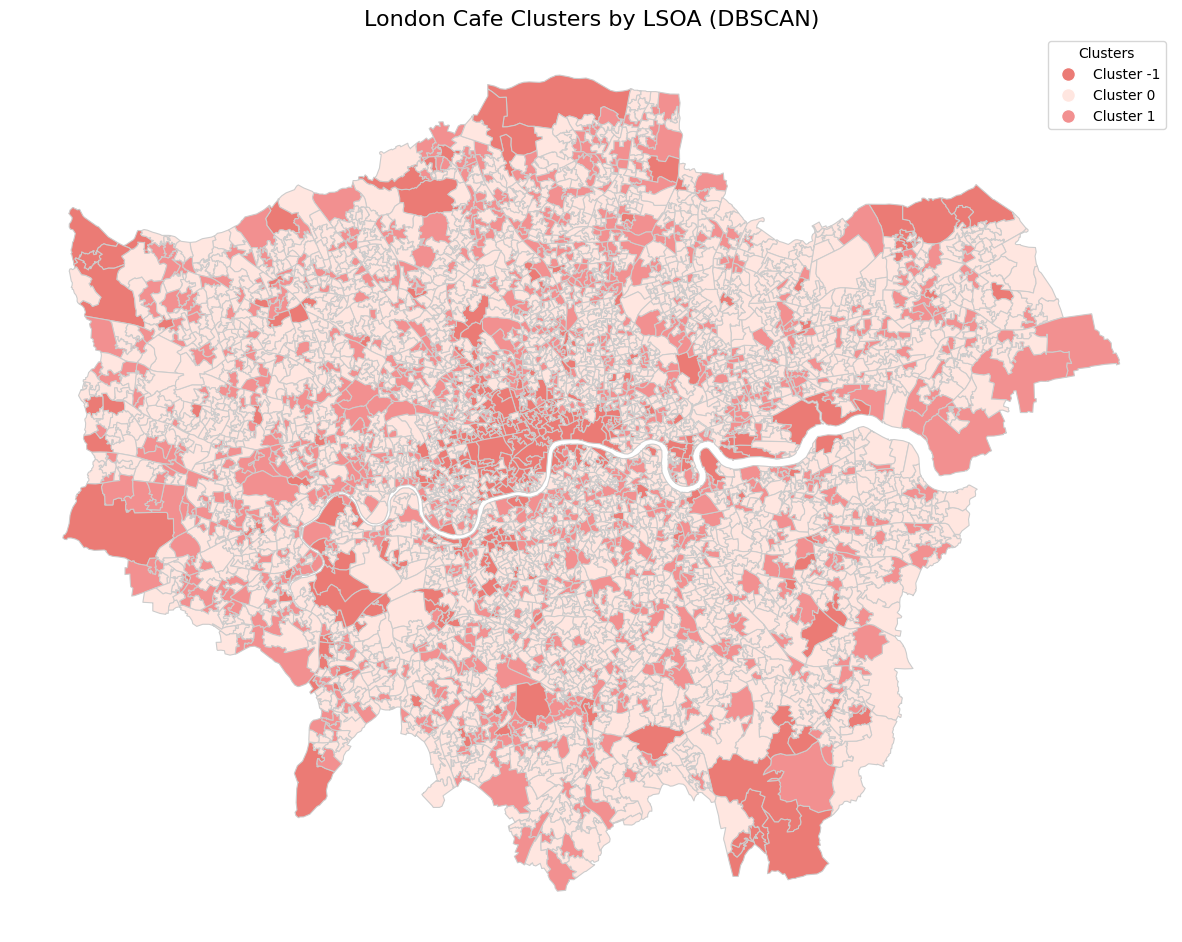

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd

# Load the shapefile
shapefile_path = 'LSOA_2011_London_gen_MHW.shp'
gdf = gpd.read_file(shapefile_path)

# Merge the GeoDataFrame with your LSOA cluster data
merged_data = pd.merge(data[['LSOA Code', 'Cluster']], gdf, left_on='LSOA Code', right_on='LSOA11CD', how='left')

# Ensure the merged_data is treated as a GeoDataFrame
merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

# Cluster colors
cluster_colors = {
    -1: '#eb7b75',  # High
     0: '#ffe6e0',  # Low
     1: '#f29090',  # Moderate
}

# Map the colors to the clusters
merged_data['color'] = merged_data['Cluster'].map(cluster_colors)

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the LSOA areas with a color map based on 'Cluster'
merged_data.plot(color=merged_data['color'], linewidth=0.8, ax=ax, edgecolor='0.8')

# Add a title
plt.title('London Cafe Clusters by LSOA (DBSCAN)', fontsize=16)

# Remove axis for better visualization
ax.set_axis_off()

# Update the legend to reflect the pastel colors
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}',
                          markersize=10, markerfacecolor=color)
                   for cluster, color in cluster_colors.items()]
ax.legend(handles=legend_elements, title='Clusters')

# Display the plot
plt.show()


